In [2]:
import pandas as pd

reddit_df = pd.read_csv(
    "../data/reddit_cleaned.csv"
)

In [3]:
reddit_df["datetime"] = pd.to_datetime(
    reddit_df["datetime"],
    errors="coerce"
)

In [4]:
documents = reddit_df["clean_text"].tolist()

In [5]:
from bertopic import BERTopic

topic_model = BERTopic(
    min_topic_size=20
)

topics, probabilities = topic_model.fit_transform(
    documents
)

c:\Users\USER\Downloads\Trending Project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3410.30it/s]


In [6]:
reddit_df["topic_id"] = topics

In [7]:
reddit_df[
    ["clean_text", "communityName", "datetime", "topic_id"]
].head(20)

,clean_text,communityName,datetime,topic_id
0,from,r/SpaceEngineering,2013-01-21,0
1,I had the idea for a reading list related to v...,r/Spaceexploration,2014-06-21,-1
2,Looks like the proton rocket issue has been re...,r/SpaceEngineering,2016-02-04,0
3,I believe the focus in space engineering going...,r/SpaceEngineering,2016-02-25,-1
4,"Here is a related article by the co-author: , ...",r/SpaceEngineering,2016-11-20,-1
5,I came across this notion and I'm not sure to ...,r/SpaceEngineering,2017-01-10,0
6,It's a technology or change to the status quo ...,r/SpaceEngineering,2017-01-10,-1
7,Thanks appreciated!,r/SpaceEngineering,2017-01-10,0
8,Many thanks to @inharmsway for allowing me to ...,r/spacetourism,2017-03-02,0
9,So I'm really interested in space and engineer...,r/SpaceEngineering,2017-08-21,-1


In [8]:
topic_info = topic_model.get_topic_info()

print(topic_info.head(20))

   Topic  Count                                   Name  \
0     -1   1746                       -1_the_to_and_of   
1      0   3060                        0_the_to_and_of   
2      1     32  1_10_earn2tip_v0120240111tip_archived   
3      2     29                 2_launch_spacex_mc_row   

                                      Representation  \
0     [the, to, and, of, is, in, that, it, you, for]   
1     [the, to, and, of, is, it, in, that, you, for]   
2  [10, earn2tip, v0120240111tip, archived, archi...   
3  [launch, spacex, mc, row, may, 2025, jun, the,...   

                                 Representative_Docs  
0  [Bad luck... It's not like this is SpaceX's fi...  
1  [So I, 16M, went to see a psychiatrist for the...  
2  [u/BigRon1977 has tipped u/Creative_Ad7831 1.0...  
3  [[]( # Welcome to the r/SpaceX Starlink 15-6 L...  


In [9]:
topic_model.get_topic(0)

[('the', np.float64(0.07592325191877061)),
 ('to', np.float64(0.06437806303525472)),
 ('and', np.float64(0.06121507101052511)),
 ('of', np.float64(0.04624871945439382)),
 ('is', np.float64(0.04374990721840304)),
 ('it', np.float64(0.04265945022868175)),
 ('in', np.float64(0.04188265112478182)),
 ('that', np.float64(0.03951846742688294)),
 ('you', np.float64(0.0392656095474919)),
 ('for', np.float64(0.03489205812871453))]

In [14]:
reddit_df["month"] = reddit_df["datetime"].dt.to_period("M")

In [15]:
topic_monthly = (
    reddit_df
    .groupby(["month", "topic_id"])
    .size()
    .reset_index(name="mention_count")
)

In [16]:
# 1) Keep only valid topics
topic_monthly = (
    reddit_df.loc[reddit_df["topic_id"] != -1]
    .groupby(["month", "topic_id"], as_index=False)
    .size()
    .rename(columns={"size": "mention_count"})
    .sort_values(["month", "topic_id"])
)

# 2) Get topic names from BERTopic
topic_info = topic_model.get_topic_info()
topic_info = topic_info[topic_info["Topic"] != -1][["Topic", "Name", "Representation"]]

topic_monthly = topic_monthly.merge(
    topic_info.rename(columns={"Topic": "topic_id", "Name": "topic_name"}),
    on="topic_id",
    how="left"
)

# 3) Show the topic with labels
print(topic_monthly.head(20))

      month  topic_id  mention_count              topic_name  \
0   2013-01         0              1         0_the_to_and_of   
1   2016-02         0              1         0_the_to_and_of   
2   2017-01         0              2         0_the_to_and_of   
3   2017-03         0              1         0_the_to_and_of   
4   2018-11         0              2         0_the_to_and_of   
5   2019-06         0              1         0_the_to_and_of   
6   2019-10         0              1         0_the_to_and_of   
7   2020-04         0              1         0_the_to_and_of   
8   2020-06         0              1         0_the_to_and_of   
9   2020-10         0              1         0_the_to_and_of   
10  2021-02         0              1         0_the_to_and_of   
11  2021-05         0              1         0_the_to_and_of   
12  2021-06         0              1         0_the_to_and_of   
13  2021-07         0              1         0_the_to_and_of   
14  2022-04         0              1    

In [17]:
topic_3 = topic_monthly[topic_monthly["topic_id"] == 3].copy()
topic_3["month"] = topic_3["month"].dt.to_timestamp()
topic_3 = topic_3.sort_values("month")

print(topic_3)

Empty DataFrame
Columns: [month, topic_id, mention_count, topic_name, Representation]
Index: []


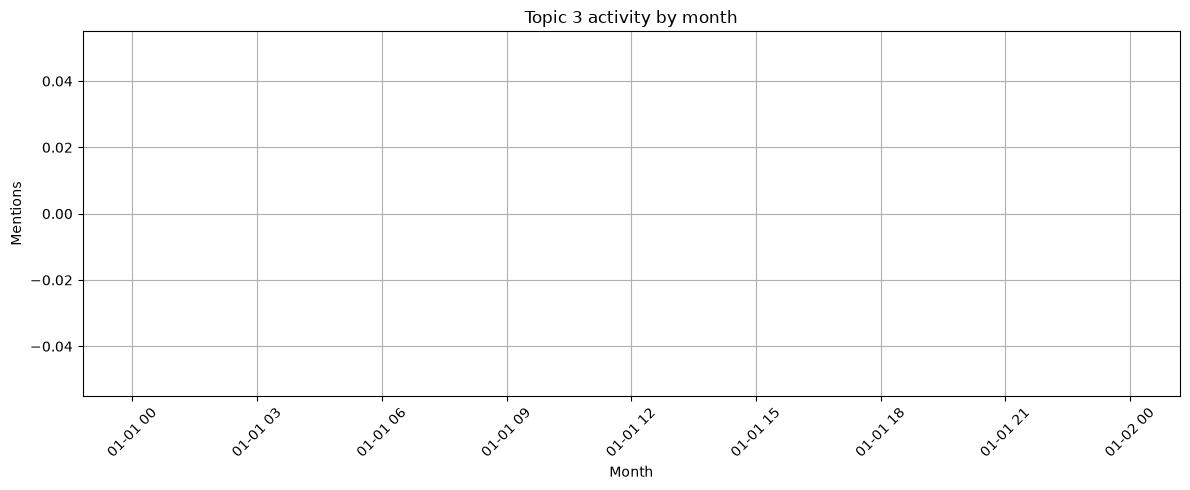

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(topic_3["month"], topic_3["mention_count"], marker="o", linewidth=2)
plt.title("Topic 3 activity by month")
plt.xlabel("Month")
plt.ylabel("Mentions")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


In [19]:
monthly_total = (
    reddit_df.loc[reddit_df["topic_id"] != -1]
    .groupby("month", as_index=False)
    .size()
    .rename(columns={"size": "total_posts"})
)

topic_monthly = topic_monthly.merge(monthly_total, on="month", how="left")
topic_monthly["topic_share"] = topic_monthly["mention_count"] / topic_monthly["total_posts"]

print(topic_monthly[topic_monthly["topic_id"] == 3][["month", "mention_count", "topic_share"]])

Empty DataFrame
Columns: [month, mention_count, topic_share]
Index: []


In [20]:
topic_3 = topic_monthly[topic_monthly["topic_id"] == 3].sort_values("month").copy()
topic_3["pct_change"] = topic_3["mention_count"].pct_change().fillna(0)
print(topic_3[["month", "mention_count", "pct_change"]])

Empty DataFrame
Columns: [month, mention_count, pct_change]
Index: []


In [21]:
from transformers import pipeline

toxicity_model = pipeline(
    "text-classification",
    model="unitary/toxic-bert"
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1890.53it/s]


In [22]:
import pandas as pd

reddit_df = pd.read_csv(
    "../data/reddit_cleaned.csv"
)

print(reddit_df.shape)

(4934, 9)


In [23]:
reddit_df.head()

,text,label,dataType,communityName,datetime,username_encoded,url_encoded,clean_text,month
0,Please include your reddit username in the sub...,r/art,comment,r/Art,2025-06-21,Z0FBQUFBQm9WeWdnajUwTE5UUm5mZFJ4LUNzSTRNemhrbk...,Z0FBQUFBQm9WeWdqM19PSDQ4UTVDSHVqamFQeWdraHVLY2...,Please include your reddit username in the sub...,2025-06
1,more than 400 MB for a corny joke?,r/mac,comment,r/mac,2025-06-20,Z0FBQUFBQm9WaDVfaDlaZk03X2Vfa3ZSMWE1ZV9kYkZ0Wj...,Z0FBQUFBQm9WaDZDa1BRMEVacTUzOW1VeGcyM3M3bU0zd3...,more than 400 MB for a corny joke?,2025-06
2,What should rattle Americans even more is that...,r/politics,comment,r/politics,2025-06-21,Z0FBQUFBQm9WeWdpTi1UemNRVkZVN0FyV2syUU5jeVEtU1...,Z0FBQUFBQm9WeWdrYlEzblcxMjRQcGJYY1RFVDh1YXhlTz...,What should rattle Americans even more is that...,2025-06
3,The 0% is only for the part in parentheses. I ...,r/worldnews,comment,r/worldnews,2025-06-20,Z0FBQUFBQm9WaDZCX3V6SHNFTXlZQ3dmbi0taTZNSXdKVW...,Z0FBQUFBQm9WaDZGaUkzc1FsQmVHcDM4b1N4R2VydFJCU3...,The 0% is only for the part in parentheses. I ...,2025-06
4,"It really pissed me off, my wife was tired but...",r/aitah,comment,r/AITAH,2025-06-20,Z0FBQUFBQm9WaDVfMFU4QkE1MUpTaml4cGhqV2RKVS0zaE...,Z0FBQUFBQm9WaDZEMl9aS3FuRUMyeUhVRWlMQktISENlSz...,"It really pissed me off, my wife was tired but...",2025-06


In [24]:
print(reddit_df.columns.tolist())

['text', 'label', 'dataType', 'communityName', 'datetime', 'username_encoded', 'url_encoded', 'clean_text', 'month']


In [25]:
documents = reddit_df["clean_text"].tolist()

print("Number of documents:", len(documents))

Number of documents: 4934


In [26]:
from bertopic import BERTopic

BERT Topic

In [27]:
topic_model = BERTopic(
    min_topic_size=20
)

In [28]:
topics, probabilities = topic_model.fit_transform(
    documents
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4849.29it/s]


In [29]:
reddit_df["topic_id"] = topics

In [30]:
reddit_df[
    ["clean_text", "communityName", "datetime", "topic_id"]
].head(20)

,clean_text,communityName,datetime,topic_id
0,Please include your reddit username in the sub...,r/Art,2025-06-21,0
1,more than 400 MB for a corny joke?,r/mac,2025-06-20,-1
2,What should rattle Americans even more is that...,r/politics,2025-06-21,-1
3,The 0% is only for the part in parentheses. I ...,r/worldnews,2025-06-20,0
4,"It really pissed me off, my wife was tired but...",r/AITAH,2025-06-20,0
5,Urine the army now,r/tech,2025-06-21,-1
6,What an interesting reality this sycophant liv...,r/politics,2025-06-21,0
7,Do you? I dont,r/teenagers,2025-06-20,0
8,Living the regard's dream,r/wallstreetbets,2025-06-21,0
9,I usually get into an m+ 2-10 group as DPS in ...,r/wow,2025-06-20,-1


In [31]:
topic_info = topic_model.get_topic_info()

print(topic_info.head(20))

   Topic  Count                Name  \
0     -1   3197    -1_the_to_and_of   
1      0   1600    0_the_to_and_you   
2      1     85     1_the_to_and_is   
3      2     52  2_the_of_israel_to   

                                      Representation  \
0     [the, to, and, of, is, in, that, it, for, you]   
1     [the, to, and, you, it, is, of, in, that, for]   
2  [the, to, and, is, trump, democrats, of, that,...   
3  [the, of, israel, to, and, in, is, iran, that,...   

                                 Representative_Docs  
0  [2 out of 3 of those at 80 years plus. Its abo...  
1  [When my ex (30f) was pregnant with our son (1...  
2  [Trump is a threat to democracy. Jailing oppen...  
3  [Palestinias support Hamas, mainly in Gaza but...  


In [32]:
topic_model.get_topic(0)

[('the', np.float64(0.07050699982630441)),
 ('to', np.float64(0.06569521423353288)),
 ('and', np.float64(0.05861479174372696)),
 ('you', np.float64(0.04964854671103861)),
 ('it', np.float64(0.04557340485131528)),
 ('is', np.float64(0.039689479997047784)),
 ('of', np.float64(0.03903491706857079)),
 ('in', np.float64(0.036903771299256954)),
 ('that', np.float64(0.036043430459410095)),
 ('for', np.float64(0.03361415208215449))]

In [33]:
print(topic_info.head(20))

   Topic  Count                Name  \
0     -1   3197    -1_the_to_and_of   
1      0   1600    0_the_to_and_you   
2      1     85     1_the_to_and_is   
3      2     52  2_the_of_israel_to   

                                      Representation  \
0     [the, to, and, of, is, in, that, it, for, you]   
1     [the, to, and, you, it, is, of, in, that, for]   
2  [the, to, and, is, trump, democrats, of, that,...   
3  [the, of, israel, to, and, in, is, iran, that,...   

                                 Representative_Docs  
0  [2 out of 3 of those at 80 years plus. Its abo...  
1  [When my ex (30f) was pregnant with our son (1...  
2  [Trump is a threat to democracy. Jailing oppen...  
3  [Palestinias support Hamas, mainly in Gaza but...  


In [34]:
for topic_id in topic_info["Topic"].head(10):
    if topic_id != -1:
        print(topic_id, topic_model.get_topic(topic_id))

0 [('the', np.float64(0.07050699982630441)), ('to', np.float64(0.06569521423353288)), ('and', np.float64(0.05861479174372696)), ('you', np.float64(0.04964854671103861)), ('it', np.float64(0.04557340485131528)), ('is', np.float64(0.039689479997047784)), ('of', np.float64(0.03903491706857079)), ('in', np.float64(0.036903771299256954)), ('that', np.float64(0.036043430459410095)), ('for', np.float64(0.03361415208215449))]
1 [('the', np.float64(0.09347323400300808)), ('to', np.float64(0.0753907775620287)), ('and', np.float64(0.07137210520292044)), ('is', np.float64(0.053306361763386094)), ('trump', np.float64(0.04972071180690245)), ('democrats', np.float64(0.04532691177266757)), ('of', np.float64(0.04506068707327049)), ('that', np.float64(0.04375516816463584)), ('people', np.float64(0.04083628955501911)), ('this', np.float64(0.03775020028539123))]
2 [('the', np.float64(0.10109220537919641)), ('of', np.float64(0.0722031534794742)), ('israel', np.float64(0.06777288880355378)), ('to', np.float

In [35]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

In [36]:
vectorizer_model = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5
)

In [37]:
topic_model = BERTopic(
    vectorizer_model=vectorizer_model,
    min_topic_size=20
)

In [38]:
topic_model = BERTopic(
    vectorizer_model=vectorizer_model,
    min_topic_size=20
)

In [48]:
documents = reddit_df["clean_text"].tolist()

In [51]:
import pandas as pd

# load data only if it is not already loaded
if "reddit_df" not in globals():
    reddit_df = pd.read_csv("../data/reddit_cleaned.csv")
    reddit_df["datetime"] = pd.to_datetime(reddit_df["datetime"], errors="coerce")

# make sure the column exists
if "clean_text" not in reddit_df.columns:
    raise KeyError("clean_text column not found in reddit_df")

reddit_df = reddit_df[
    reddit_df["clean_text"].fillna("").str.strip() != ""
].reset_index(drop=True)

documents = reddit_df["clean_text"].astype(str).tolist()

print("Number of documents:", len(documents))

print("Number of documents:", len(documents))

Number of documents: 4934
Number of documents: 4934


In [52]:
import numba
import llvmlite
import umap

print("Numba:", numba.__version__)
print("llvmlite:", llvmlite.__version__)
print("UMAP:", umap.__version__)

Numba: 0.67.0
llvmlite: 0.49.0
UMAP: 0.5.12


In [54]:
import pandas as pd

# load data only if needed
if "reddit_df" not in globals():
    reddit_df = pd.read_csv("../data/reddit_cleaned.csv")
    reddit_df["datetime"] = pd.to_datetime(reddit_df["datetime"], errors="coerce")

# verify required column exists
if "clean_text" not in reddit_df.columns:
    raise KeyError("clean_text column not found in reddit_df")

documents = reddit_df["clean_text"].fillna("").astype(str).tolist()

print("Number of documents:", len(documents))

Number of documents: 4934


In [55]:
top_100 = (
    reddit_df["communityName"]
    .value_counts()
    .head(100)
    .reset_index()
)

top_100.columns = ["communityName", "count"]

print(top_100.shape)
print(top_100.head())

(54, 2)
      communityName  count
0        r/politics   1260
1       r/worldnews    968
2  r/wallstreetbets    534
3      r/technology    322
4             r/wow    226


In [57]:
import numba
import llvmlite
import umap

print("Numba:", numba.__version__)
print("llvmlite:", llvmlite.__version__)
print("UMAP:", umap.__version__)

Numba: 0.67.0
llvmlite: 0.49.0
UMAP: 0.5.12


In [58]:
from umap import UMAP
import numpy as np

X = np.random.rand(100, 10)

umap_model = UMAP(
    n_components=2,
    random_state=42
)

result = umap_model.fit_transform(X)

print(result.shape)

AttributeError: module 'numba' has no attribute 'utils'

In [59]:
import sys

print(sys.executable)

c:\Users\USER\Downloads\Trending Project\venv\Scripts\python.exe


In [1]:
import sys
print(sys.executable)

c:\Users\USER\Downloads\Trending Project\.venv-1\Scripts\python.exe


In [2]:
import sys

print(sys.executable)

c:\Users\USER\Downloads\Trending Project\.venv-1\Scripts\python.exe


In [3]:
import umap

print("UMAP version:", umap.__version__)
print("UMAP location:", umap.__file__)

ModuleNotFoundError: No module named 'umap'

In [5]:
import sys
print(sys.executable)

c:\Users\USER\Downloads\Trending Project\.venv-1\Scripts\python.exe


In [6]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "umap-learn"
])

0

In [1]:
import sys
print(sys.executable)

c:\Users\USER\Downloads\Trending Project\.venv-1\Scripts\python.exe


In [2]:
import umap

print("UMAP version:", umap.__version__)
print("UMAP location:", umap.__file__)

c:\Users\USER\Downloads\Trending Project\.venv-1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


UMAP version: 0.5.12
UMAP location: c:\Users\USER\Downloads\Trending Project\.venv-1\Lib\site-packages\umap\__init__.py


In [3]:
from umap import UMAP
import numpy as np

X = np.random.rand(100, 10)

umap_model = UMAP(
    n_components=2,
    random_state=42
)

result = umap_model.fit_transform(X)

print(result.shape)

c:\Users\USER\Downloads\Trending Project\.venv-1\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(100, 2)


In [8]:
import pandas
import numpy
import sklearn
import bertopic
import sentence_transformers
import umap

print("All required packages imported successfully!")

ModuleNotFoundError: No module named 'pandas'

In [9]:
import sys
print(sys.executable)

c:\Users\USER\Downloads\Trending Project\.venv-1\Scripts\python.exe


In [10]:
import sys
import subprocess

packages = [
    "pandas",
    "numpy",
    "scikit-learn",
    "bertopic",
    "sentence-transformers"
]

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    *packages
])

0

In [1]:
import pandas as pd
import numpy as np
import sklearn
import bertopic
import sentence_transformers
import umap

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)
print("BERTopic:", bertopic.__version__)
print("Sentence Transformers:", sentence_transformers.__version__)
print("UMAP:", umap.__version__)

print("\nAll required packages imported successfully!")

c:\Users\USER\Downloads\Trending Project\.venv-1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Pandas: 3.0.5
NumPy: 2.5.2
Scikit-learn: 1.9.0
BERTopic: 0.17.4
Sentence Transformers: 6.0.0
UMAP: 0.5.12

All required packages imported successfully!


In [2]:
import pandas as pd

reddit_df = pd.read_csv("../data/reddit_cleaned.csv")

reddit_df["datetime"] = pd.to_datetime(
    reddit_df["datetime"],
    errors="coerce"
)

reddit_df = reddit_df.dropna(
    subset=["clean_text", "datetime"]
).copy()

reddit_df["clean_text"] = (
    reddit_df["clean_text"]
    .fillna("")
    .astype(str)
)

reddit_df = reddit_df[
    reddit_df["clean_text"].str.strip() != ""
].reset_index(drop=True)

documents = reddit_df["clean_text"].tolist()

print("Rows:", len(reddit_df))
print("Documents:", len(documents))

Rows: 4934
Documents: 4934


In [3]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_model = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5
)

print("Vectorizer created successfully")

Vectorizer created successfully


In [4]:
from bertopic import BERTopic

topic_model = BERTopic(
    vectorizer_model=vectorizer_model,
    min_topic_size=20,
    verbose=True
)

print("BERTopic model created successfully")

BERTopic model created successfully


In [5]:
topics, probabilities = topic_model.fit_transform(documents)

2026-08-30 11:55:54,005 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 155/155 [00:30<00:00,  5.05it/s]
2026-08-30 11:56:35,929 - BERTopic - Embedding - Completed ✓
2026-08-30 11:56:35,930 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-08-30 11:57:13,116 - BERTopic - Dimensionality - Completed ✓
2026-08-30 11:57:13,121 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-30 11:57:14,042 - BERTopic - Cluster - Completed ✓
2026-08-30 11:57:14,074 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-30 11:57:16,497 - BERTopic - Representation - Completed ✓


In [6]:
print("Topic modeling completed!")
print("Number of documents:", len(topics))

Topic modeling completed!
Number of documents: 4934


In [7]:
reddit_df["topic_id"] = topics

print(reddit_df[["clean_text", "topic_id"]].head(10))

                                          clean_text  topic_id
0  Please include your reddit username in the sub...        19
1                 more than 400 MB for a corny joke?        -1
2  What should rattle Americans even more is that...         0
3  The 0% is only for the part in parentheses. I ...        -1
4  It really pissed me off, my wife was tired but...         4
5                                 Urine the army now        20
6  What an interesting reality this sycophant liv...        -1
7                                     Do you? I dont        -1
8                          Living the regard's dream        -1
9  I usually get into an m+ 2-10 group as DPS in ...         3


In [8]:
topic_info = topic_model.get_topic_info()

print(topic_info.head(20))

    Topic  Count                                         Name  \
0      -1   2151                     -1_just_people_like_dont   
1       0    387                 0_trump_democrats_party_vote   
2       1    300                1_iran_israel_nuclear_weapons   
3       2    169                      2_use_app_internet_like   
4       3    163                       3_game_play_season_set   
5       4    161                          4_told_said_wife_im   
6       5    134                      5_lmao_lol_true_exactly   
7       6    127                    6_money_puts_calls_market   
8       7    125                         7_eat_weight_im_food   
9       8    112                8_war_protest_countries_fight   
10      9    109                  9_launch_base_flight_planes   
11     10     93             10_weeks_week_day_infrastructure   
12     11     87                11_russia_ukraine_russian_war   
13     12     72                      12_coin_buy_value_money   
14     13     72         

In [9]:
for topic_id in topic_info["Topic"]:
    
    if topic_id == -1:
        continue
    
    print("\nTopic:", topic_id)
    print(topic_model.get_topic(topic_id)[:10])


Topic: 0
[('trump', np.float64(0.04695324958035136)), ('democrats', np.float64(0.04104312150824919)), ('party', np.float64(0.03862882024305806)), ('vote', np.float64(0.03242064215630525)), ('republicans', np.float64(0.027990222877169884)), ('election', np.float64(0.027439241049206028)), ('people', np.float64(0.025109401737330152)), ('biden', np.float64(0.018971383103586408)), ('hes', np.float64(0.01779164627879783)), ('just', np.float64(0.017414745088942533))]

Topic: 1
[('iran', np.float64(0.09245625610891348)), ('israel', np.float64(0.07545263909880039)), ('nuclear', np.float64(0.05637109190965483)), ('weapons', np.float64(0.031017103131592807)), ('nuke', np.float64(0.024371154610701648)), ('war', np.float64(0.024350001817845624)), ('nukes', np.float64(0.024184489062784073)), ('regime', np.float64(0.020151805832768627)), ('attack', np.float64(0.019045191279356635)), ('irans', np.float64(0.016947960947403983))]

Topic: 2
[('use', np.float64(0.030462324488739027)), ('app', np.float64(

In [10]:
topic_names = {
    0: "Politics",
    1: "Technology",
    2: "World Affairs"
}


In [11]:
reddit_df["topic_name"] = reddit_df["topic_id"].map(topic_names)

reddit_df["topic_name"] = reddit_df["topic_name"].fillna(
    "Other"
)

In [12]:
reddit_df.to_csv(
    "../data/reddit_with_topics.csv",
    index=False
)

print("Saved successfully!")

Saved successfully!


In [13]:
reddit_df["month"] = reddit_df["datetime"].dt.to_period("M")

monthly_topics = (
    reddit_df[reddit_df["topic_id"] != -1]
    .groupby(["month", "topic_id"])
    .size()
    .reset_index(name="count")
)

print(monthly_topics.head(20))

      month  topic_id  count
0   2020-09        15      1
1   2024-11        15      1
2   2024-11        20      1
3   2025-01        27      1
4   2025-02         4      1
5   2025-04         4      1
6   2025-04         9      2
7   2025-05         9      3
8   2025-05        28      1
9   2025-06         0    387
10  2025-06         1    300
11  2025-06         2    169
12  2025-06         3    163
13  2025-06         4    159
14  2025-06         5    134
15  2025-06         6    127
16  2025-06         7    125
17  2025-06         8    112
18  2025-06         9    104
19  2025-06        10     93


In [14]:
monthly_topics["previous_count"] = (
    monthly_topics
    .groupby("topic_id")["count"]
    .shift(1)
)

monthly_topics["growth"] = (
    monthly_topics["count"] -
    monthly_topics["previous_count"]
)

In [15]:
print(monthly_topics.head(20))

      month  topic_id  count  previous_count  growth
0   2020-09        15      1             NaN     NaN
1   2024-11        15      1             1.0     0.0
2   2024-11        20      1             NaN     NaN
3   2025-01        27      1             NaN     NaN
4   2025-02         4      1             NaN     NaN
5   2025-04         4      1             1.0     0.0
6   2025-04         9      2             NaN     NaN
7   2025-05         9      3             2.0     1.0
8   2025-05        28      1             NaN     NaN
9   2025-06         0    387             NaN     NaN
10  2025-06         1    300             NaN     NaN
11  2025-06         2    169             NaN     NaN
12  2025-06         3    163             NaN     NaN
13  2025-06         4    159             1.0   158.0
14  2025-06         5    134             NaN     NaN
15  2025-06         6    127             NaN     NaN
16  2025-06         7    125             NaN     NaN
17  2025-06         8    112             NaN  

In [16]:
monthly_topics["growth_percent"] = (
    monthly_topics["growth"] /
    monthly_topics["previous_count"].replace(0, pd.NA)
) * 100

In [17]:
latest_month = monthly_topics["month"].max()

print("Latest month:", latest_month)

Latest month: 2025-06


In [18]:
latest_trends = (
    monthly_topics[
        monthly_topics["month"] == latest_month
    ]
    .sort_values(
        "count",
        ascending=False
    )
)

print(latest_trends.head(10))

      month  topic_id  count  previous_count  growth  growth_percent
9   2025-06         0    387             NaN     NaN             NaN
10  2025-06         1    300             NaN     NaN             NaN
11  2025-06         2    169             NaN     NaN             NaN
12  2025-06         3    163             NaN     NaN             NaN
13  2025-06         4    159             1.0   158.0    15800.000000
14  2025-06         5    134             NaN     NaN             NaN
15  2025-06         6    127             NaN     NaN             NaN
16  2025-06         7    125             NaN     NaN             NaN
17  2025-06         8    112             NaN     NaN             NaN
18  2025-06         9    104             3.0   101.0     3366.666667


In [19]:
from transformers import pipeline

toxicity_model = pipeline(
    "text-classification",
    model="unitary/toxic-bert"
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 678.96it/s]


In [20]:
from transformers import pipeline

toxicity_model = pipeline(
    "text-classification",
    model="unitary/toxic-bert"
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 966.94it/s] 


In [22]:
from tqdm.auto import tqdm

reddit_texts = reddit_df["clean_text"].tolist()

toxicity_results = []

batch_size = 16

for i in tqdm(
    range(0, len(reddit_texts), batch_size),
    desc="Analyzing Reddit toxicity"
):
    
    batch = reddit_texts[i:i + batch_size]
    
    results = toxicity_model(
        batch,
        truncation=True,
        max_length=512
    )
    
    toxicity_results.extend(results)

print("Completed:", len(toxicity_results))

Analyzing Reddit toxicity: 100%|██████████| 309/309 [10:16<00:00,  1.99s/it]

Completed: 4934


In [23]:
print("Reddit rows:", len(reddit_df))
print("Toxicity results:", len(toxicity_results))

print(toxicity_results[:3])

Reddit rows: 4934
Toxicity results: 4934
[{'label': 'toxic', 'score': 0.0005916277877986431}, {'label': 'toxic', 'score': 0.0017802623333409429}, {'label': 'toxic', 'score': 0.00717072794213891}]


In [24]:
top_k=None

In [25]:
from tqdm.auto import tqdm

reddit_texts = reddit_df["clean_text"].tolist()

all_toxicity_results = []

batch_size = 16

for i in tqdm(
    range(0, len(reddit_texts), batch_size),
    desc="Getting all toxicity scores"
):
    
    batch = reddit_texts[i:i + batch_size]
    
    results = toxicity_model(
        batch,
        truncation=True,
        max_length=512,
        top_k=None
    )
    
    all_toxicity_results.extend(results)

print("Completed:", len(all_toxicity_results))

Getting all toxicity scores: 100%|██████████| 309/309 [11:17<00:00,  2.19s/it]

Completed: 4934


In [26]:
print(all_toxicity_results[0])

[{'label': 'toxic', 'score': 0.0005916277877986431}, {'label': 'obscene', 'score': 0.00017882527026813477}, {'label': 'insult', 'score': 0.0001771449897205457}, {'label': 'identity_hate', 'score': 0.00014048292359802872}, {'label': 'threat', 'score': 0.0001308178179897368}, {'label': 'severe_toxic', 'score': 0.00012501106539275497}]


In [27]:
def extract_scores(results):
    scores = {
        item["label"]: item["score"]
        for item in results
    }
    
    return (
        scores.get("toxic", 0.0),
        scores.get("insult", 0.0),
        scores.get("threat", 0.0)
    )

In [28]:
extracted = [
    extract_scores(result)
    for result in all_toxicity_results
]

reddit_df["toxicity_score"] = [
    x[0] for x in extracted
]

reddit_df["insult_score"] = [
    x[1] for x in extracted
]

reddit_df["threat_score"] = [
    x[2] for x in extracted
]

In [29]:
reddit_df[
    [
        "clean_text",
        "topic_id",
        "toxicity_score",
        "insult_score",
        "threat_score"
    ]
].head(10)

,clean_text,topic_id,toxicity_score,insult_score,threat_score
0,Please include your reddit username in the sub...,19,0.000592,0.000177,0.000131
1,more than 400 MB for a corny joke?,-1,0.001780,0.000216,0.000093
2,What should rattle Americans even more is that...,0,0.007171,0.000347,0.000193
3,The 0% is only for the part in parentheses. I ...,-1,0.000595,0.000178,0.000122
4,"It really pissed me off, my wife was tired but...",4,0.013961,0.000697,0.000189
5,Urine the army now,20,0.517020,0.015056,0.000847
6,What an interesting reality this sycophant liv...,-1,0.634583,0.352102,0.000814
7,Do you? I dont,-1,0.027739,0.000778,0.000241
8,Living the regard's dream,-1,0.000784,0.000183,0.000108
9,I usually get into an m+ 2-10 group as DPS in ...,3,0.000780,0.000185,0.000111


In [30]:
reddit_df.to_csv(
    "../data/reddit_topics_toxicity.csv",
    index=False
)

print("Saved!")

Saved!


In [31]:
reddit_df["high_toxicity"] = (
    reddit_df["toxicity_score"] >= 0.5
).astype(int)

In [32]:
print(
    reddit_df["high_toxicity"].value_counts()
)

high_toxicity
0    4378
1     556
Name: count, dtype: int64


In [33]:
valid_topics_df = reddit_df[
    reddit_df["topic_id"] != -1
].copy()

In [34]:
topic_toxicity = (
    valid_topics_df
    .groupby("topic_id")
    .agg(
        document_count=("clean_text", "size"),
        average_toxicity=("toxicity_score", "mean"),
        average_insult=("insult_score", "mean"),
        average_threat=("threat_score", "mean"),
        high_toxicity_percentage=("high_toxicity", "mean")
    )
    .reset_index()
)

In [35]:
topic_toxicity["high_toxicity_percentage"] *= 100

In [36]:
topic_toxicity.sort_values(
    "average_toxicity",
    ascending=False
).head(10)

,topic_id,document_count,average_toxicity,average_insult,average_threat,high_toxicity_percentage
20,20,42,0.376258,0.101338,0.002575,38.095238
26,26,27,0.331914,0.154203,0.002097,29.629630
4,4,161,0.196248,0.075101,0.002338,18.633540
29,29,23,0.192762,0.050648,0.024687,21.739130
13,13,72,0.175157,0.069489,0.003870,16.666667
28,28,27,0.172497,0.046402,0.000460,18.518519
0,0,387,0.168524,0.064726,0.002297,16.795866
12,12,72,0.158915,0.035871,0.000403,12.500000
11,11,87,0.158612,0.070251,0.018630,16.091954
5,5,134,0.151537,0.064251,0.001293,14.925373


In [37]:
topic_info = topic_model.get_topic_info()

In [38]:
topic_names = topic_info[
    ["Topic", "Name"]
].rename(
    columns={
        "Topic": "topic_id",
        "Name": "topic_name"
    }
)

In [39]:
topic_toxicity = topic_toxicity.merge(
    topic_names,
    on="topic_id",
    how="left"
)

In [40]:
topic_toxicity[
    [
        "topic_id",
        "topic_name",
        "average_toxicity",
        "high_toxicity_percentage"
    ]
]

,topic_id,topic_name,average_toxicity,high_toxicity_percentage
0,0,0_trump_democrats_party_vote,0.168524,16.795866
1,1,1_iran_israel_nuclear_weapons,0.108690,8.666667
2,2,2_use_app_internet_like,0.052046,4.142012
3,3,3_game_play_season_set,0.055543,5.521472
4,4,4_told_said_wife_im,0.196248,18.633540
5,5,5_lmao_lol_true_exactly,0.151537,14.925373
6,6,6_money_puts_calls_market,0.130859,12.598425
7,7,7_eat_weight_im_food,0.072377,5.600000
8,8,8_war_protest_countries_fight,0.122290,9.821429
9,9,9_launch_base_flight_planes,0.074597,7.339450


In [41]:
reddit_df["datetime"] = pd.to_datetime(
    reddit_df["datetime"],
    errors="coerce"
)

reddit_df["quarter"] = (
    reddit_df["datetime"]
    .dt.to_period("Q")
)

In [42]:
print(reddit_df["quarter"].min())
print(reddit_df["quarter"].max())

2020Q3
2025Q2


In [43]:
topic_quarterly = (
    reddit_df[
        reddit_df["topic_id"] != -1
    ]
    .groupby(
        ["quarter", "topic_id"]
    )
    .size()
    .reset_index(name="mention_count")
)

In [44]:
topic_quarterly.head(20)

,quarter,topic_id,mention_count
0,2020Q3,15,1
1,2024Q4,15,1
2,2024Q4,20,1
3,2025Q1,4,1
4,2025Q1,27,1
5,2025Q2,0,387
6,2025Q2,1,300
7,2025Q2,2,169
8,2025Q2,3,163
9,2025Q2,4,160


In [45]:
all_quarters = pd.period_range(
    reddit_df["quarter"].min(),
    reddit_df["quarter"].max(),
    freq="Q"
)

all_topics = sorted(
    reddit_df.loc[
        reddit_df["topic_id"] != -1,
        "topic_id"
    ].unique()
)


In [46]:
full_index = pd.MultiIndex.from_product(
    [all_quarters, all_topics],
    names=["quarter", "topic_id"]
)

topic_quarterly = (
    topic_quarterly
    .set_index(["quarter", "topic_id"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

In [47]:
topic_quarterly["previous_count"] = (
    topic_quarterly
    .groupby("topic_id")["mention_count"]
    .shift(1)
)

In [48]:
topic_quarterly["growth"] = (
    topic_quarterly["mention_count"]
    -
    topic_quarterly["previous_count"]
)

In [49]:
topic_quarterly["growth_rate"] = (
    topic_quarterly["growth"] /
    (topic_quarterly["previous_count"].fillna(0) + 1)
)

In [50]:
latest_quarter = topic_quarterly["quarter"].max()

print("Latest dataset quarter:", latest_quarter)

Latest dataset quarter: 2025Q2


In [51]:
latest_trends = (
    topic_quarterly[
        topic_quarterly["quarter"] == latest_quarter
    ]
    .copy()
)

In [52]:
latest_trends = latest_trends[
    latest_trends["mention_count"] > 0
].copy()

In [53]:
latest_trends.sort_values(
    "mention_count",
    ascending=False
).head(10)

,quarter,topic_id,mention_count,previous_count,growth,growth_rate
589,2025Q2,0,387,0.0,387.0,387.0
590,2025Q2,1,300,0.0,300.0,300.0
591,2025Q2,2,169,0.0,169.0,169.0
592,2025Q2,3,163,0.0,163.0,163.0
593,2025Q2,4,160,1.0,159.0,79.5
594,2025Q2,5,134,0.0,134.0,134.0
595,2025Q2,6,127,0.0,127.0,127.0
596,2025Q2,7,125,0.0,125.0,125.0
597,2025Q2,8,112,0.0,112.0,112.0
598,2025Q2,9,109,0.0,109.0,109.0


In [54]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

latest_trends[
    ["volume_norm", "growth_norm"]
] = scaler.fit_transform(
    latest_trends[
        ["mention_count", "growth"]
    ]
)

In [55]:
latest_trends["trend_score"] = (
    0.6 * latest_trends["volume_norm"]
    +
    0.4 * latest_trends["growth_norm"]
)

In [56]:
latest_trends = latest_trends.sort_values(
    "trend_score",
    ascending=False
)

In [57]:
final_results = latest_trends.merge(
    topic_toxicity,
    on="topic_id",
    how="left"
)

In [58]:
final_results[
    [
        "topic_id",
        "topic_name",
        "mention_count",
        "growth",
        "trend_score",
        "average_toxicity",
        "average_insult",
        "average_threat",
        "high_toxicity_percentage"
    ]
].head(10)

,topic_id,topic_name,mention_count,growth,trend_score,average_toxicity,average_insult,average_threat,high_toxicity_percentage
0,0,0_trump_democrats_party_vote,387,387.0,1.000000,0.168524,0.064726,0.002297,16.795866
1,1,1_iran_israel_nuclear_weapons,300,300.0,0.761644,0.108690,0.022026,0.004092,8.666667
2,2,2_use_app_internet_like,169,169.0,0.402740,0.052046,0.008857,0.000396,4.142012
3,3,3_game_play_season_set,163,163.0,0.386301,0.055543,0.010934,0.000686,5.521472
4,4,4_told_said_wife_im,160,159.0,0.376986,0.196248,0.075101,0.002338,18.633540
5,5,5_lmao_lol_true_exactly,134,134.0,0.306849,0.151537,0.064251,0.001293,14.925373
6,6,6_money_puts_calls_market,127,127.0,0.287671,0.130859,0.044228,0.000556,12.598425
7,7,7_eat_weight_im_food,125,125.0,0.282192,0.072377,0.006306,0.000338,5.600000
8,8,8_war_protest_countries_fight,112,112.0,0.246575,0.122290,0.036959,0.007233,9.821429
9,9,9_launch_base_flight_planes,109,109.0,0.238356,0.074597,0.022215,0.001006,7.339450


MAIN RESULT OF THE PROJECT 

In [59]:
final_results["trend_status"] = pd.cut(
    final_results["trend_score"],
    bins=[-0.01, 0.33, 0.66, 1.0],
    labels=["Low", "Medium", "High"]
)

final_results["toxicity_status"] = pd.cut(
    final_results["average_toxicity"],
    bins=[-0.01, 0.33, 0.66, 1.0],
    labels=["Low", "Medium", "High"]
)

In [60]:
final_results.to_csv(
    "../data/final_trend_toxicity_results.csv",
    index=False
)

print("FINAL RESULTS SAVED!")

FINAL RESULTS SAVED!


In [2]:
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'matplotlib'

In [4]:
py -m pip install matplotlib

SyntaxError: invalid syntax (3534672589.py, line 1)

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(topic_3["month"], topic_3["mention_count"], marker="o", linewidth=2)
plt.title("Topic 3 activity by month")
plt.xlabel("Month")
plt.ylabel("Mentions")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'matplotlib'

In [6]:
import matplotlib.pyplot as plt

top10 = final_results.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["topic_name"],
    top10["trend_score"]
)

plt.xlabel("Trend Score")
plt.ylabel("Topic")
plt.title("Top Historical Trending Topics")

plt.gca().invert_yaxis()

plt.show()

ModuleNotFoundError: No module named 'matplotlib'

In [7]:
import sys
!{sys.executable} -m pip install matplotlib

'c:\Users\USER\Downloads\Trending' is not recognized as an internal or external command,
operable program or batch file.


In [8]:
import sys

print(sys.executable)

c:\Users\USER\Downloads\Trending Project\.venv-1\Scripts\python.exe


In [9]:
import sys
print(sys.executable)

!{sys.executable} -m pip install matplotlib

c:\Users\USER\Downloads\Trending Project\.venv-1\Scripts\python.exe


'c:\Users\USER\Downloads\Trending' is not recognized as an internal or external command,
operable program or batch file.


In [10]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "matplotlib"
])

0

In [12]:
import matplotlib
import matplotlib.pyplot as plt

print("Matplotlib version:", matplotlib.__version__)
print("Matplotlib is working!")

Matplotlib version: 3.11.1
Matplotlib is working!


In [13]:
print(final_results.shape)

print(final_results.columns.tolist())

display(final_results.head(10))

NameError: name 'final_results' is not defined

In [14]:
print("reddit_df exists:", "reddit_df" in globals())
print("topic_model exists:", "topic_model" in globals())
print("topic_info exists:", "topic_info" in globals())
print("toxicity_results exists:", "toxicity_results" in globals())
print("all_toxicity_results exists:", "all_toxicity_results" in globals())

reddit_df exists: False
topic_model exists: False
topic_info exists: False
toxicity_results exists: False
all_toxicity_results exists: False


In [15]:
import pandas as pd
import os

reddit_df = pd.read_csv("../data/reddit_cleaned.csv")

print("Shape:", reddit_df.shape)
print("Columns:")
print(reddit_df.columns.tolist())

Shape: (4934, 9)
Columns:
['text', 'label', 'dataType', 'communityName', 'datetime', 'username_encoded', 'url_encoded', 'clean_text', 'month']


In [16]:
import os

print(os.listdir("../data"))

['aggression_analysis_sample.csv', 'cleaned_civil_comments.csv', 'final_trend_toxicity_results.csv', 'reddit_cleaned.csv', 'reddit_topics_toxicity.csv', 'reddit_with_topics.csv', 'toxicity_validation_results.csv']


In [17]:
print(reddit_df.head(2))
print(reddit_df.columns.tolist())

                                                text  label dataType  \
0  Please include your reddit username in the sub...  r/art  comment   
1                 more than 400 MB for a corny joke?  r/mac  comment   

  communityName    datetime  \
0         r/Art  2025-06-21   
1         r/mac  2025-06-20   

                                    username_encoded  \
0  Z0FBQUFBQm9WeWdnajUwTE5UUm5mZFJ4LUNzSTRNemhrbk...   
1  Z0FBQUFBQm9WaDVfaDlaZk03X2Vfa3ZSMWE1ZV9kYkZ0Wj...   

                                         url_encoded  \
0  Z0FBQUFBQm9WeWdqM19PSDQ4UTVDSHVqamFQeWdraHVLY2...   
1  Z0FBQUFBQm9WaDZDa1BRMEVacTUzOW1VeGcyM3M3bU0zd3...   

                                          clean_text    month  
0  Please include your reddit username in the sub...  2025-06  
1                 more than 400 MB for a corny joke?  2025-06  
['text', 'label', 'dataType', 'communityName', 'datetime', 'username_encoded', 'url_encoded', 'clean_text', 'month']


In [18]:
from bertopic import BERTopic

c:\Users\USER\Downloads\Trending Project\.venv-1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [19]:
documents = reddit_df["clean_text"].fillna("").astype(str).tolist()

print("Number of documents:", len(documents))

Number of documents: 4934


In [20]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

print("Embedding model loaded")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2423.80it/s]


Embedding model loaded


In [21]:
embeddings = embedding_model.encode(
    documents,
    show_progress_bar=True
)

print("Embedding shape:", embeddings.shape)

Batches: 100%|██████████| 155/155 [00:31<00:00,  4.86it/s]

Embedding shape: (4934, 384)


In [22]:
from umap import UMAP
from hdbscan import HDBSCAN

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=20,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    verbose=True
)

In [24]:
topics, probabilities = topic_model.fit_transform(
    documents,
    embeddings
)

print("Topic modeling completed")
print("Number of documents:", len(topics))

2026-08-30 16:20:54,816 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-08-30 16:21:07,165 - BERTopic - Dimensionality - Completed ✓
2026-08-30 16:21:07,166 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-30 16:21:07,315 - BERTopic - Cluster - Completed ✓
2026-08-30 16:21:07,322 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-30 16:21:07,436 - BERTopic - Representation - Completed ✓


Topic modeling completed
Number of documents: 4934


In [25]:
reddit_df["topic_id"] = topics

print(reddit_df[["clean_text", "topic_id"]].head())

                                          clean_text  topic_id
0  Please include your reddit username in the sub...        14
1                 more than 400 MB for a corny joke?        -1
2  What should rattle Americans even more is that...         0
3  The 0% is only for the part in parentheses. I ...        -1
4  It really pissed me off, my wife was tired but...        12


In [26]:
topic_info = topic_model.get_topic_info()

display(topic_info.head(10))

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1812,-1_the_it_to_and,"[the, it, to, and, is, you, that, of, in, this]",[I'm hoping I'm not the only one who sees what...
1,0,423,0_the_he_trump_and,"[the, he, trump, and, to, of, is, that, democr...",[2 out of 3 of those at 80 years plus. Its abo...
2,1,417,1_you_bitcoin_it_is,"[you, bitcoin, it, is, the, money, to, and, th...",[XRP and XLM were both created by the Mt.Gox F...
3,2,304,2_iran_israel_the_nuclear,"[iran, israel, the, nuclear, to, of, they, and...",[They built an enrichment site in a mountain a...
4,3,178,3_it_the_and_to,"[it, the, and, to, you, my, mac, apple, for, in]","[For those who feel a ""throbbing"" sensation wh..."
5,4,178,4_the_they_to_and,"[the, they, to, and, of, that, ice, slavery, p...",[Head of the committee that added this amendme...
6,5,153,5_the_and_game_for,"[the, and, game, for, it, to, is, of, with, on]","[For the vast majority of players, this is sim..."
7,6,146,6_what_lmao_lol_you,"[what, lmao, lol, you, true, exactly, this, ta...","[what, What's that?, Lol what?]"
8,7,122,7_he_his_chocopro_the,"[he, his, chocopro, the, her, of, is, wrestlin...",[Ugh. Can't stand Smith. He is the living embo...
9,8,115,8_you_and_it_keto,"[you, and, it, keto, protein, to, my, of, eat,...","[The only reason you gain real weight, body fa..."


In [27]:
print(reddit_df["topic_id"].value_counts().head(10))

topic_id
-1    1812
 0     423
 1     417
 2     304
 4     178
 3     178
 5     153
 6     146
 7     122
 8     115
Name: count, dtype: int64


In [28]:
display(topic_info.head(10))

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1812,-1_the_it_to_and,"[the, it, to, and, is, you, that, of, in, this]",[I'm hoping I'm not the only one who sees what...
1,0,423,0_the_he_trump_and,"[the, he, trump, and, to, of, is, that, democr...",[2 out of 3 of those at 80 years plus. Its abo...
2,1,417,1_you_bitcoin_it_is,"[you, bitcoin, it, is, the, money, to, and, th...",[XRP and XLM were both created by the Mt.Gox F...
3,2,304,2_iran_israel_the_nuclear,"[iran, israel, the, nuclear, to, of, they, and...",[They built an enrichment site in a mountain a...
4,3,178,3_it_the_and_to,"[it, the, and, to, you, my, mac, apple, for, in]","[For those who feel a ""throbbing"" sensation wh..."
5,4,178,4_the_they_to_and,"[the, they, to, and, of, that, ice, slavery, p...",[Head of the committee that added this amendme...
6,5,153,5_the_and_game_for,"[the, and, game, for, it, to, is, of, with, on]","[For the vast majority of players, this is sim..."
7,6,146,6_what_lmao_lol_you,"[what, lmao, lol, you, true, exactly, this, ta...","[what, What's that?, Lol what?]"
8,7,122,7_he_his_chocopro_the,"[he, his, chocopro, the, her, of, is, wrestlin...",[Ugh. Can't stand Smith. He is the living embo...
9,8,115,8_you_and_it_keto,"[you, and, it, keto, protein, to, my, of, eat,...","[The only reason you gain real weight, body fa..."


In [29]:
reddit_df["datetime"] = pd.to_datetime(
    reddit_df["datetime"],
    errors="coerce"
)

reddit_df["month"] = reddit_df["datetime"].dt.to_period("M")

monthly_topics = (
    reddit_df[reddit_df["topic_id"] != -1]
    .groupby(["month", "topic_id"])
    .size()
    .reset_index(name="mention_count")
)

print(monthly_topics.head())

     month  topic_id  mention_count
0  2024-11        19              1
1  2025-01        27              1
2  2025-04         9              2
3  2025-05         3              1
4  2025-05         9              3


In [30]:
monthly_topics = monthly_topics.sort_values(
    ["topic_id", "month"]
)

monthly_topics["previous_count"] = (
    monthly_topics
    .groupby("topic_id")["mention_count"]
    .shift(1)
)

monthly_topics["growth"] = (
    monthly_topics["mention_count"]
    - monthly_topics["previous_count"].fillna(0)
)

print(monthly_topics.tail())

      month  topic_id  mention_count  previous_count  growth
33  2025-06        26             26             NaN    26.0
1   2025-01        27              1             NaN     1.0
34  2025-06        27             23             1.0    22.0
6   2025-05        28              1             NaN     1.0
35  2025-06        28             20             1.0    19.0


In [31]:
from sklearn.preprocessing import MinMaxScaler

latest_month = monthly_topics["month"].max()

latest_topics = monthly_topics[
    monthly_topics["month"] == latest_month
].copy()

scaler = MinMaxScaler()

latest_topics[
    ["volume_norm", "growth_norm"]
] = scaler.fit_transform(
    latest_topics[["mention_count", "growth"]]
)

latest_topics["trend_score"] = (
    0.6 * latest_topics["volume_norm"]
    + 0.4 * latest_topics["growth_norm"]
)

print(latest_topics.sort_values(
    "trend_score",
    ascending=False
).head(10))

      month  topic_id  mention_count  previous_count  growth  volume_norm  \
7   2025-06         0            423             NaN   423.0     1.000000   
8   2025-06         1            417             NaN   417.0     0.985112   
9   2025-06         2            304             NaN   304.0     0.704715   
11  2025-06         4            178             NaN   178.0     0.392060   
10  2025-06         3            177             1.0   176.0     0.389578   
12  2025-06         5            153             NaN   153.0     0.330025   
13  2025-06         6            146             NaN   146.0     0.312655   
14  2025-06         7            122             NaN   122.0     0.253102   
15  2025-06         8            115             NaN   115.0     0.235732   
16  2025-06         9            108             3.0   105.0     0.218362   

    growth_norm  trend_score  
7      1.000000     1.000000  
8      0.985149     0.985126  
9      0.705446     0.705007  
11     0.393564     0.392661

In [32]:
topic_names = topic_info[
    ["Topic", "Name"]
].rename(
    columns={
        "Topic": "topic_id",
        "Name": "topic_name"
    }
)

latest_topics = latest_topics.merge(
    topic_names,
    on="topic_id",
    how="left"
)

display(
    latest_topics[
        ["topic_id", "topic_name", "mention_count",
         "growth", "trend_score"]
    ].sort_values(
        "trend_score",
        ascending=False
    ).head(10)
)

,topic_id,topic_name,mention_count,growth,trend_score
0,0,0_the_he_trump_and,423,423.0,1.000000
1,1,1_you_bitcoin_it_is,417,417.0,0.985126
2,2,2_iran_israel_the_nuclear,304,304.0,0.705007
4,4,4_the_they_to_and,178,178.0,0.392661
3,3,3_it_the_and_to,177,176.0,0.389192
5,5,5_the_and_game_for,153,153.0,0.330688
6,6,6_what_lmao_lol_you,146,146.0,0.313336
7,7,7_he_his_chocopro_the,122,122.0,0.253841
8,8,8_you_and_it_keto,115,115.0,0.236489
9,9,9_the_launch_they_may,108,105.0,0.216166


In [33]:
latest_topics.to_csv(
    "../data/trending_topics.csv",
    index=False
)

print("Trending topics saved successfully.")

Trending topics saved successfully.


In [34]:
print(reddit_df.columns.tolist())

['text', 'label', 'dataType', 'communityName', 'datetime', 'username_encoded', 'url_encoded', 'clean_text', 'month', 'topic_id']


In [35]:
from transformers import pipeline

toxicity_model = pipeline(
    "text-classification",
    model="unitary/toxic-bert",
    top_k=None
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2349.46it/s]


In [36]:
from tqdm.auto import tqdm

reddit_texts = reddit_df["clean_text"].fillna("").astype(str).tolist()

toxicity_results = []

batch_size = 16

for i in tqdm(
    range(0, len(reddit_texts), batch_size),
    desc="Analyzing Reddit toxicity"
):
    batch = reddit_texts[i:i + batch_size]

    results = toxicity_model(
        batch,
        truncation=True,
        max_length=512
    )

    toxicity_results.extend(results)

print("Completed:", len(toxicity_results))

Analyzing Reddit toxicity: 100%|██████████| 309/309 [19:27<00:00,  3.78s/it]

Completed: 4934


In [37]:
def get_score(result, label):
    for item in result:
        if item["label"].lower() == label:
            return item["score"]
    return 0.0

reddit_df["toxicity_score"] = [
    get_score(r, "toxic")
    for r in toxicity_results
]

reddit_df["insult_score"] = [
    get_score(r, "insult")
    for r in toxicity_results
]

reddit_df["threat_score"] = [
    get_score(r, "threat")
    for r in toxicity_results
]

print(
    reddit_df[
        ["toxicity_score", "insult_score", "threat_score"]
    ].head()
)

   toxicity_score  insult_score  threat_score
0        0.000592      0.000177      0.000131
1        0.001780      0.000216      0.000093
2        0.007171      0.000347      0.000193
3        0.000595      0.000178      0.000122
4        0.013961      0.000697      0.000189


In [38]:
topic_toxicity = (
    reddit_df[reddit_df["topic_id"] != -1]
    .groupby("topic_id")
    .agg(
        average_toxicity=("toxicity_score", "mean"),
        average_insult=("insult_score", "mean"),
        average_threat=("threat_score", "mean")
    )
    .reset_index()
)

display(topic_toxicity.head())

,topic_id,average_toxicity,average_insult,average_threat
0,0,0.171737,0.067067,0.002178
1,1,0.108977,0.034367,0.000800
2,2,0.108904,0.023163,0.004057
3,3,0.069834,0.016339,0.000448
4,4,0.133868,0.044504,0.009649


In [40]:
final_results = latest_topics.merge(
    topic_toxicity,
    on="topic_id",
    how="left"
)

final_results = final_results.sort_values(
    "trend_score",
    ascending=False
).reset_index(drop=True)

display(
    final_results[
        [
            "topic_id",
            "topic_name",
            "mention_count",
            "growth",
            "trend_score",
            "average_toxicity",
            "average_insult",
            "average_threat"
        ]
    ].head(10)
)

,topic_id,topic_name,mention_count,growth,trend_score,average_toxicity,average_insult,average_threat
0,0,0_the_he_trump_and,423,423.0,1.000000,0.171737,0.067067,0.002178
1,1,1_you_bitcoin_it_is,417,417.0,0.985126,0.108977,0.034367,0.000800
2,2,2_iran_israel_the_nuclear,304,304.0,0.705007,0.108904,0.023163,0.004057
3,4,4_the_they_to_and,178,178.0,0.392661,0.133868,0.044504,0.009649
4,3,3_it_the_and_to,177,176.0,0.389192,0.069834,0.016339,0.000448
5,5,5_the_and_game_for,153,153.0,0.330688,0.054725,0.008159,0.000734
6,6,6_what_lmao_lol_you,146,146.0,0.313336,0.130476,0.039858,0.001191
7,7,7_he_his_chocopro_the,122,122.0,0.253841,0.202051,0.088214,0.003029
8,8,8_you_and_it_keto,115,115.0,0.236489,0.065612,0.005849,0.000333
9,9,9_the_launch_they_may,108,105.0,0.216166,0.065145,0.020860,0.000972


In [41]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

final_results[
    ["trend_norm", "toxicity_norm"]
] = scaler.fit_transform(
    final_results[
        ["trend_score", "average_toxicity"]
    ]
)

final_results["combined_score"] = (
    0.6 * final_results["trend_norm"]
    + 0.4 * final_results["toxicity_norm"]
)

final_results = final_results.sort_values(
    "combined_score",
    ascending=False
).reset_index(drop=True)

display(final_results.head(10))

,month,topic_id,mention_count,previous_count,growth,volume_norm,growth_norm,trend_score,topic_name,average_toxicity,average_insult,average_threat,trend_norm,toxicity_norm,combined_score
0,2025-06,0,423,NaN,423.0,1.000000,1.000000,1.000000,0_the_he_trump_and,0.171737,0.067067,0.002178,1.000000,0.475370,0.790148
1,2025-06,1,417,NaN,417.0,0.985112,0.985149,0.985126,1_you_bitcoin_it_is,0.108977,0.034367,0.000800,0.985126,0.295278,0.709187
2,2025-06,2,304,NaN,304.0,0.704715,0.705446,0.705007,2_iran_israel_the_nuclear,0.108904,0.023163,0.004057,0.705007,0.295070,0.541032
3,2025-06,26,26,NaN,26.0,0.014888,0.017327,0.015864,26_racist_people_black_matter,0.354566,0.160345,0.002209,0.015864,1.000000,0.409518
4,2025-06,19,48,1.0,47.0,0.069479,0.069307,0.069410,19_my_nyuk_pillows_water,0.304783,0.078280,0.001721,0.069410,0.857147,0.384505
5,2025-06,4,178,NaN,178.0,0.392060,0.393564,0.392661,4_the_they_to_and,0.133868,0.044504,0.009649,0.392661,0.366705,0.382279
6,2025-06,7,122,NaN,122.0,0.253102,0.254950,0.253841,7_he_his_chocopro_the,0.202051,0.088214,0.003029,0.253841,0.562355,0.377247
7,2025-06,6,146,NaN,146.0,0.312655,0.314356,0.313336,6_what_lmao_lol_you,0.130476,0.039858,0.001191,0.313336,0.356970,0.330789
8,2025-06,3,177,1.0,176.0,0.389578,0.388614,0.389192,3_it_the_and_to,0.069834,0.016339,0.000448,0.389192,0.182959,0.306699
9,2025-06,12,77,NaN,77.0,0.141439,0.143564,0.142289,12_he_she_him_me,0.196337,0.059169,0.001732,0.142289,0.545959,0.303757


In [42]:
final_results.to_csv(
    "../data/final_trending_aggression_results.csv",
    index=False
)

print("Final results saved successfully.")

Final results saved successfully.


In [43]:
print(final_results.shape)
print(final_results.columns.tolist())
display(final_results.head(10))

(29, 15)
['month', 'topic_id', 'mention_count', 'previous_count', 'growth', 'volume_norm', 'growth_norm', 'trend_score', 'topic_name', 'average_toxicity', 'average_insult', 'average_threat', 'trend_norm', 'toxicity_norm', 'combined_score']


,month,topic_id,mention_count,previous_count,growth,volume_norm,growth_norm,trend_score,topic_name,average_toxicity,average_insult,average_threat,trend_norm,toxicity_norm,combined_score
0,2025-06,0,423,NaN,423.0,1.000000,1.000000,1.000000,0_the_he_trump_and,0.171737,0.067067,0.002178,1.000000,0.475370,0.790148
1,2025-06,1,417,NaN,417.0,0.985112,0.985149,0.985126,1_you_bitcoin_it_is,0.108977,0.034367,0.000800,0.985126,0.295278,0.709187
2,2025-06,2,304,NaN,304.0,0.704715,0.705446,0.705007,2_iran_israel_the_nuclear,0.108904,0.023163,0.004057,0.705007,0.295070,0.541032
3,2025-06,26,26,NaN,26.0,0.014888,0.017327,0.015864,26_racist_people_black_matter,0.354566,0.160345,0.002209,0.015864,1.000000,0.409518
4,2025-06,19,48,1.0,47.0,0.069479,0.069307,0.069410,19_my_nyuk_pillows_water,0.304783,0.078280,0.001721,0.069410,0.857147,0.384505
5,2025-06,4,178,NaN,178.0,0.392060,0.393564,0.392661,4_the_they_to_and,0.133868,0.044504,0.009649,0.392661,0.366705,0.382279
6,2025-06,7,122,NaN,122.0,0.253102,0.254950,0.253841,7_he_his_chocopro_the,0.202051,0.088214,0.003029,0.253841,0.562355,0.377247
7,2025-06,6,146,NaN,146.0,0.312655,0.314356,0.313336,6_what_lmao_lol_you,0.130476,0.039858,0.001191,0.313336,0.356970,0.330789
8,2025-06,3,177,1.0,176.0,0.389578,0.388614,0.389192,3_it_the_and_to,0.069834,0.016339,0.000448,0.389192,0.182959,0.306699
9,2025-06,12,77,NaN,77.0,0.141439,0.143564,0.142289,12_he_she_him_me,0.196337,0.059169,0.001732,0.142289,0.545959,0.303757


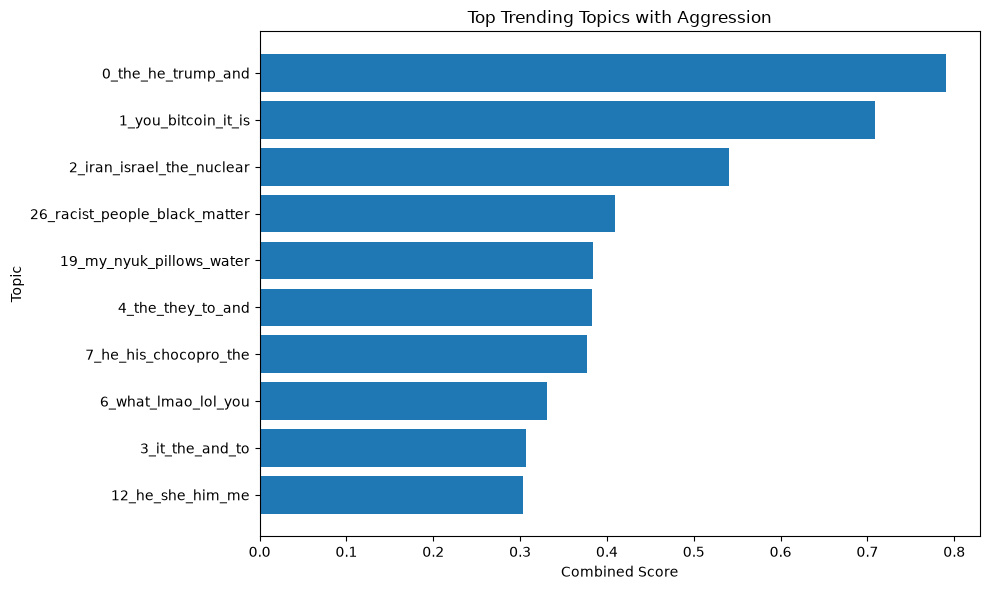

In [44]:
import matplotlib.pyplot as plt

top10 = final_results.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["topic_name"].astype(str),
    top10["combined_score"]
)

plt.xlabel("Combined Score")
plt.ylabel("Topic")
plt.title("Top Trending Topics with Aggression")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [45]:
final_results.to_csv(
    "../data/final_trending_aggression_results.csv",
    index=False
)

print("Final dataset saved successfully.")

Final dataset saved successfully.


In [46]:
reddit_df.to_csv(
    "../data/reddit_final_analysis.csv",
    index=False
)

print("Reddit analysis data saved successfully.")

Reddit analysis data saved successfully.
